In [1]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [3]:
def pi_reshape(side):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

In [4]:
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [5]:
# IC & TO detection
def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """
    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    IC_side = [rfd_1500[0]]

    # next IC of the same side has to be at least 250 ms away (fs/4)
    for i in range(1, len(rfd_1500)):
        if rfd_1500[i] - rfd_1500[i - 1] > sampling_rate / 4:
            IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side

In [6]:
# extract steps and save in dict
def pi_separate_steps(pi_left, pi_right, pi_events):
    """
    separates the Stance phases for each step and save in dict
    :param pi_left: pressure data left foot 3d array shape [31 x 11 x frames]
    :param pi_right: pressure data right foot 3d array shape [31 x 11 x frames]
    :param pi_events: dict with IC and TO indices for each side
    :return pi_steps: dict with data for each step (stance phase) - values 3d array[31 x 11 x [IC:TO]]
    """
    # init dict
    pi_steps = {}

    # left side
    for i in range(len(pi_events['IC_left'])):
        pi_steps['left_'+str(i)]=pi_left[:,:,pi_events['IC_left'][i]:pi_events['TO_left'][i]]
    # right side
    for i in range(len(pi_events['IC_right'])):
        pi_steps['right_'+str(i)]=pi_right[:,:,pi_events['IC_right'][i]:pi_events['TO_right'][i]]

    return pi_steps

In [8]:
# get COP coordinates for all steps and save in dict
def pi_get_cop(pi_steps):
    """
    calculates COP coordinates for all steps
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return cop_dict: dict with COP coordinates as pd.DataFrame (columns = [x, y]) for each step
    """
    # init dict
    cop_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init array for coordinates
        x = np.empty(pi_steps[key].shape[2])
        y = np.empty(pi_steps[key].shape[2])

        # calculate center of mass for each frame
        for frame in range(pi_steps[key].shape[2]):
            y[frame], x[frame]  = ndimage.measurements.center_of_mass(pi_steps[key][:,:,frame])

        # save COP coordinates (time series) in data frame) & append to dict
        cop_dict[key]=pd.DataFrame([x,y], index = ['x', 'y']).T

    return cop_dict


In [63]:
# calculate F, p, A for all steps and safe in dict
def pi_get_fpa(pi_steps, sensor_size):
    """
    calculates Force, Pressure & Contact Area Time Series for each step
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return fpa: dict with Force, Pressure, Area TS as pd.DataFrame (columns = [Force, Area, Pressure]) for each step
    """
    # init dict
    fpa_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init arrays for F, A
        f = np.empty(pi_steps[key].shape[2])
        a = np.empty(pi_steps[key].shape[2])
        p = np.empty(pi_steps[key].shape[2])

        # calculate parameters for each frame
        for frame in range(pi_steps[key].shape[2]):
            # Area: count all non-zero sensors, multiply by sensor size
            a[frame] = np.count_nonzero(pi_steps[key][:,:,frame])*sensor_size
            # Force: sum up all pressure values
            f[frame] = np.sum(pi_steps[key][:,:,frame])
            # pressure = F/A when A=!0
            if a[frame]==0:
                p[frame]=0
            else:
                p[frame]=f[frame]/a[frame]

        # save Parameters  (time series) in data frame) & append to dict
        fpa_dict[key] = pd.DataFrame([f, p, a], index=['Force', 'Pressure', 'Area']).T

    return fpa_dict

In [10]:
def pi_dict_resample(input_dict, output_length):
    """
    Resamples Parameters for each Step at a given length into Multi-index DF
    :param input_dict: dict with Parameters as pd DataFrame for each step
    :param output_length: integer with desired output length
    :return df_resampled: Multi-Index DF, first level: parameters, second level: steps
    """
    # get list with steps
    steps = list(input_dict.keys())
    # get list with parameters
    parameters = list(list(input_dict.values())[0].columns)

    # resample dict via dict comprehension and re-create pd DataFrame as Dict Values
    dict_resampled = {key:pd.DataFrame(resample(value,output_length), columns= value.columns) for (key,value) in input_dict.items()}

    # initialize nested dict
    nested_dict = {}
    # extract each parameter in separate dict & nest
    for i in range(len(parameters)):
        nested_dict[parameters[i]] = {key: value.iloc[:,i] for (key,value) in dict_resampled.items()}

    # create multiindex df
    dict_of_df = {k: pd.DataFrame(v) for k, v in nested_dict.items()}
    df_resampled = pd.concat(dict_of_df, axis = 1)

    return df_resampled


In [67]:
# optional: Foot Segmetation

# Segmentation in 6 Segments (Medial-Lateral, Forefoot, Midfoot, Rearfoot)
def foot_segmentation(array3):
    forefoot = array3[0:11, :, :]
    midfoot = array3[11:21, :, :]
    rearfoot = array3[21:, :, :]

    if rearfoot[:, 0:6].mean() > rearfoot[:, 6:].mean():
        # if left pressure is bigger than right --> left foot --> needs to be flipped
        forefoot = np.fliplr(forefoot)
        midfoot = np.fliplr(midfoot)
        rearfoot = np.fliplr(rearfoot)

    def med_lat_slice(segment):
        med = segment[:, 0:6, :]
        lat = segment[:, 6:, :]
        return med, lat

    ffm, ffl = med_lat_slice(forefoot)
    mfm, mfl = med_lat_slice(midfoot)
    rfm, rfl = med_lat_slice(rearfoot)

    slices = {'FF_Med': ffm,
              'FF_Lat': ffl,
              'MF_Med': mfm,
              'MF_Lat': mfl,
              'RF_Med': rfm,
              'RF_Lat': rfl}

    return slices

## Example

In [13]:
df = pd.read_csv(r'C:\Users\b1090197\Desktop\xSensorParser\dfFiles\S01_A_120_01.csv')

In [14]:
df

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,foot,frame,row_count
0,0,0.0,0.0,0.0,0.0,0.00,1.28,0.0,0.00,0.00,0.00,0.0,left,1,1
1,1,0.0,0.0,0.0,0.0,1.14,1.09,0.0,1.07,1.99,0.00,0.0,left,1,2
2,2,0.0,0.0,0.0,0.0,0.00,0.00,0.0,1.62,2.40,1.17,0.0,left,1,3
3,3,0.0,0.0,0.9,0.0,0.00,0.00,0.0,0.00,1.73,2.19,0.0,left,1,4
4,4,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,left,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248057,372071,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,right,4001,27
248058,372072,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,right,4001,28
248059,372073,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,right,4001,29
248060,372074,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,right,4001,30


In [15]:
left, right = separate_sides(df)

In [17]:
left.shape

(31, 11, 4001)

In [92]:
left[0,0,:]

array([0., 0., 0., ..., 0., 0., 0.])

In [21]:
force_left = pi_force(left)
force_right = pi_force(right)

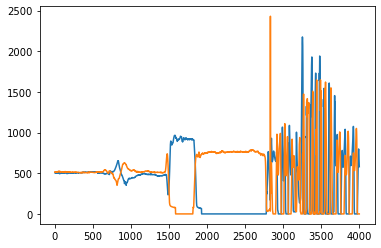

In [25]:
plt.plot(force_left)
plt.plot(force_right)

In [30]:
# get Contact Events
events_dict = pi_step_segmentation(force_left, force_right, 100) # sampling rate = 100 Hz?
events_dict

{'IC_left': array([ 937, 1499, 2777, 2831, 2910, 2977, 3068, 3159, 3229, 3301, 3347,
        3412, 3472, 3525, 3587, 3658, 3759, 3867]),
 'IC_right': array([1812, 2830, 2900, 3008, 3103, 3174, 3253, 3296, 3477, 3537, 3614,
        3695, 3800]),
 'TO_left': array([1927, 1927, 2935, 2935, 2935, 3036, 3272, 3272, 3272, 3323, 3396,
        3440, 3493, 3554, 3589, 3721, 3828, 3937], dtype=int64),
 'TO_right': array([2865, 2865, 2973, 3066, 3232, 3232, 3279, 3348, 3508, 3575, 3653,
        3759, 3867], dtype=int64)}

In [31]:
# separate Steps
steps_dict = pi_separate_steps(left, right, events_dict)
steps_dict

{'left_0': array([[[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         ...,
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ]],
 
        [[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         ...,
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ]],
 
        [[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         ...,
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
         [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ]],
 
   

In [32]:
# calculate COP
cop_dict = pi_get_cop(steps_dict)
cop_dict

{'left_0':             x          y
 0    3.986854  19.661688
 1    3.601747  19.706675
 2    3.573946  19.737863
 3    3.567315  19.705968
 4    3.558640  19.724330
 ..        ...        ...
 985  2.195250  20.898392
 986  2.193281  20.884604
 987  2.199879  20.902395
 988  2.183947  20.791138
 989  2.213827  20.897522
 
 [990 rows x 2 columns],
 'left_1':             x          y
 0    3.133228  18.199620
 1    3.152640  18.280332
 2    3.180585  18.330888
 3    3.199888  18.394153
 4    3.209686  18.506764
 ..        ...        ...
 423  2.195250  20.898392
 424  2.193281  20.884604
 425  2.199879  20.902395
 426  2.183947  20.791138
 427  2.213827  20.897522
 
 [428 rows x 2 columns],
 'left_2':             x          y
 0    1.896478  15.517609
 1    2.034454  15.360254
 2    2.002236  15.304065
 3    1.887190  15.650648
 4    2.264571  19.444004
 ..        ...        ...
 153  7.816721   9.567663
 154  7.853488   9.467442
 155  7.804447   9.364944
 156  7.869601   9.352078
 157  

In [75]:
# calculate force, pressure, area dict
sensor_size = .82**2
fpa_dict = pi_get_fpa(steps_dict, sensor_size)
# resample to 100 samples per step & convert to Multiindex DF
whole_fpa_df = pi_dict_resample(fpa_dict, 100)
whole_fpa_df

Force                                                              \
        left_0      left_1      left_2      left_3      left_4      left_5   
0   236.245779  239.311979   21.372764  168.451041  700.590000    5.920000   
1   411.751693  441.603742   42.831633  191.956666  786.653488   41.771909   
2   390.452839  531.135508   74.522620  222.573998  804.458475   93.812341   
3   441.930708  703.265741  189.716268  255.954460  773.415386  177.864093   
4   428.448605  808.760859  269.501077  304.324574  725.280000  329.989057   
..         ...         ...         ...         ...         ...         ...   
95   77.901168   66.170671   55.562775   39.645060  -58.279394   34.097353   
96   82.681264   76.846035   40.453972   36.089718   21.700000   27.948741   
97   65.230034   59.853520   38.485620   30.097602  169.027320   35.108763   
98   85.004054   80.740382   30.772493   26.229614  358.320625   31.744486   
99   41.018749   43.079658   22.956722   20.028482  549.098993    8.759524   

                                                   ...       Area             \
        left_6      left_7      left_8     left_9  ...    right_3    right_4   
0    -0.398556   25.466018  196.400000  18.350000  ...   1.344800   4.889525   
1   220.040359   48.525040  230.451243 -33.698139  ...   8.191959   9.017665   
2   665.821610   70.318736  226.203537 -69.594756  ...  23.448478  20.600478   
3   826.745430  115.455742  219.445101 -62.717714  ...  38.168500  33.465379   
4   773.486346  179.378255  234.840685   6.936519  ...  45.378387  39.101475   
..         ...         ...         ...        ...  ...        ...        ...   
95  542.944530   50.528855   31.474360  33.534110  ...  38.857787  10.637477   
96   76.727153   40.691009    8.728373  57.668309  ...  32.635169   7.620422   
97   68.456505   30.003624    0.554538  78.931619  ...  22.799905   6.999026   
98   25.380084   26.051257   39.620273  83.271952  ...  12.038105   7.863398   
99   35.888712   20.236829  119.802475  62.282460  ...   3.881755   8.046788   

                                                                      \
      right_5    right_6    right_7    right_8    right_9   right_10   
0    8.741200   8.741200   5.379200   5.379200   5.379200   4.706800   
1   10.922608   5.016842   5.314867   2.999954   5.928499  12.191822   
2   14.642123   3.037769   5.383056   3.070386   5.830423  19.909006   
3   19.750855   5.407174   5.396106   4.889008   5.069658  24.353671   
4   25.143896  13.804107   5.377307   6.813168   4.583821  26.844102   
..        ...        ...        ...        ...        ...        ...   
95   7.326418  20.273513  20.984003  26.761987  10.554933  13.270308   
96   7.598978  16.509008  18.781956  23.196004   8.104573  11.792982   
97   8.345939  14.799699  13.897762  19.222080   6.515360   8.659856   
98   8.208589  13.787743   9.039286  14.609079   5.417046   4.191539   
99   7.905306  11.969550   6.257425   9.657812   5.007341   1.803342   

                          
     right_11   right_12  
0   11.430800   3.362000  
1   19.640524  14.598422  
2   30.224130  28.668225  
3   37.820106  31.619448  
4   40.601448  35.040723  
..        ...        ...  
95  26.952380  43.834923  
96  22.727483  36.663639  
97  16.530078  32.300652  
98   9.188055  28.494745  
99   7.154415  13.735418  

[100 rows x 93 columns]

In [37]:
steps_dict.keys()

dict_keys(['left_0', 'left_1', 'left_2', 'left_3', 'left_4', 'left_5', 'left_6', 'left_7', 'left_8', 'left_9', 'left_10', 'left_11', 'left_12', 'left_13', 'left_14', 'left_15', 'left_16', 'left_17', 'right_0', 'right_1', 'right_2', 'right_3', 'right_4', 'right_5', 'right_6', 'right_7', 'right_8', 'right_9', 'right_10', 'right_11', 'right_12'])

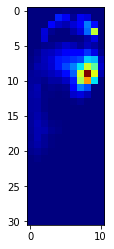

In [72]:
# example step
ex = steps_dict['left_11']
# plot mean of example step
plt.imshow(np.mean(ex, axis=2), cmap='jet', interpolation='nearest')

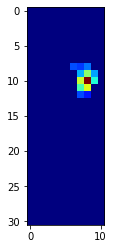

In [73]:
# create animation
fig, ax = plt.subplots()
ims=[]
for i in range(ex.shape[2]):
    im=ax.imshow(ex[:,:,0+i], animated=True, cmap='jet', interpolation='nearest')
    if i==0:
        ax.imshow(ex[:,:,0], cmap='jet', interpolation='nearest')
    ims.append([im])

ani=animation.ArtistAnimation(fig, ims, interval=26.6, blit=True, repeat_delay=10)
f = r"C:\Users\b1090197\Documents\Python\Untitled Folder\julian.gif"
writergif = animation.PillowWriter(fps=26.6)
ani.save(f, writer=writergif)

## Segmentation

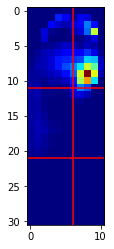

In [68]:
plt.imshow(np.mean(ex, axis=2), cmap='jet', interpolation='nearest')
plt.vlines(6, -0.5, 30.5, colors='r')
plt.hlines([11,21], -0.5, 10.5, colors='r')

In [69]:
# create segment dicts
ff_med_dict = {}
ff_lat_dict = {}
mf_med_dict = {}
mf_lat_dict = {}
rf_med_dict = {}
rf_lat_dict = {}

for key in steps_dict.keys():
    slices = foot_segmentation(steps_dict[key])
    ff_med_dict[key]=slices['FF_Med']
    ff_lat_dict[key]=slices['FF_Lat']
    mf_med_dict[key]=slices['MF_Med']
    mf_lat_dict[key]=slices['MF_Lat']
    rf_med_dict[key]=slices['RF_Med']
    rf_lat_dict[key]=slices['RF_Lat']

In [70]:
# calculate force, pressure, area in each segment
ff_med_fpa_dict = pi_get_fpa(ff_med_dict, sensor_size)
ff_lat_fpa_dict = pi_get_fpa(ff_lat_dict, sensor_size)
mf_med_fpa_dict = pi_get_fpa(mf_med_dict, sensor_size)
mf_lat_fpa_dict = pi_get_fpa(mf_lat_dict, sensor_size)
rf_med_fpa_dict = pi_get_fpa(rf_med_dict, sensor_size)
rf_lat_fpa_dict = pi_get_fpa(rf_lat_dict, sensor_size)
# resample to 100 samples per step & convert to Multiindex DF
ff_med_fpa_df = pi_dict_resample(ff_med_fpa_dict, 100)
ff_lat_fpa_df = pi_dict_resample(ff_lat_fpa_dict, 100)
mf_med_fpa_df = pi_dict_resample(mf_med_fpa_dict, 100)
mf_lat_fpa_df = pi_dict_resample(mf_lat_fpa_dict, 100)
rf_med_fpa_df = pi_dict_resample(rf_med_fpa_dict, 100)
rf_lat_fpa_df = pi_dict_resample(rf_lat_fpa_dict, 100)

In [71]:
rf_lat_fpa_df['Pressure']

,left_0,left_1,left_2,left_3,left_4,left_5,left_6,left_7,left_8,left_9,...,right_3,right_4,right_5,right_6,right_7,right_8,right_9,right_10,right_11,right_12
0,3.592462,2.897588,-0.163694,1.555198,1.971297e+00,6.744134e-15,-0.004465,-0.009644,1.652425e-16,-3.229740e-15,...,0.000000,0.108260,4.594026e-16,1.283958,-4.235928e-15,-9.168293e-16,-1.121910e-15,-7.287618e-16,1.531826,1.199683
1,5.114269,4.603478,0.712586,1.984266,2.185549e+00,1.184249e+00,5.931813,0.010852,3.321776e-02,-1.040612e+00,...,0.683828,-0.022270,-1.117032e-01,1.005705,4.551801e-02,-1.969730e-02,-1.621917e-01,4.816972e-01,3.263189,2.252532
2,4.971729,6.132967,1.575212,1.880150,2.205857e+00,2.540761e+00,15.192727,-0.012071,1.449109e-02,-1.532534e+00,...,1.968313,0.001852,3.615291e-02,0.690281,-6.404205e-03,-2.718716e-02,-1.257371e-01,1.536825e+00,5.280869,3.638237
3,5.528705,8.058753,2.638922,1.886906,2.097894e+00,4.350633e+00,16.750932,0.013302,-2.692483e-02,-9.185967e-01,...,3.879492,0.007391,3.902801e-02,0.742017,-5.531278e-02,-7.618019e-03,8.232138e-02,3.003761e+00,6.910016,5.106714
4,5.421364,8.959513,4.217960,1.921532,1.955681e+00,7.729918e+00,13.602343,-0.014493,-2.632160e-02,1.207207e+00,...,6.713664,-0.013321,-3.407967e-02,1.550137,1.526736e-02,2.801961e-02,2.030530e-01,4.526761e+00,7.710115,5.887229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.749589,1.829546,0.060791,-0.037591,-2.554365e-01,-1.717759e-02,0.030695,0.002728,-1.589531e-02,1.615256e+00,...,-0.008347,1.608722,1.216744e+00,-0.304241,2.138371e-02,7.063758e-03,-3.918649e-02,-4.519678e-03,-0.028118,-0.031191
96,1.899314,1.903103,-0.059163,0.033296,4.263256e-16,-1.149375e-01,-0.042994,-0.004380,2.676056e-02,1.909308e+00,...,-0.028153,0.117919,9.931575e-01,-0.060083,5.031528e-05,1.241580e-03,-1.336445e-01,-1.941884e-02,0.059018,0.041779
97,1.725055,1.822890,0.063738,-0.030949,4.518739e-01,1.004994e-01,0.058388,0.005839,2.725950e-02,2.033750e+00,...,0.031649,1.114155,1.156506e+00,0.405589,1.403021e-02,7.295711e-04,-6.017265e-02,-2.387602e-03,-0.020880,0.002341
98,2.014291,1.935972,-0.075037,0.030682,1.013132e+00,1.025451e-01,-0.079855,-0.007172,-1.461057e-02,1.779451e+00,...,0.029423,1.158551,1.160629e+00,0.923817,3.096295e-03,7.821571e-03,1.020438e-01,-1.389606e-02,-0.110546,-0.113756


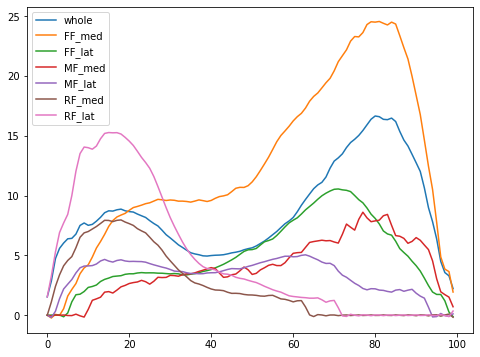

In [86]:
# plot pressure in all segments for a given step
plt.plot(whole_fpa_df['Pressure']['right_11'], label = 'whole')
plt.plot(ff_med_fpa_df['Pressure']['right_11'], label = 'FF_med')
plt.plot(ff_lat_fpa_df['Pressure']['right_11'], label = 'FF_lat')
plt.plot(mf_med_fpa_df['Pressure']['right_11'], label = 'MF_med')
plt.plot(mf_lat_fpa_df['Pressure']['right_11'], label = 'MF_lat')
plt.plot(rf_med_fpa_df['Pressure']['right_11'], label = 'RF_med')
plt.plot(rf_lat_fpa_df['Pressure']['right_11'], label = 'RF_lat')
plt.legend()
plt.rcParams["figure.figsize"] = (10,6)